# 0. Распаковка датасета

In [ ]:
import zipfile
import os 

# Путь к архиву с датасетом
zip_path = "dataset.zip"
extract_path = "dataset"

if os.path.exists(zip_path):
    print("Распаковка датасета...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Датасет распакован.")
else:
    print("Архив с датасетом не найден, пропускаем распаковку.")


# 1. Импорт библиотек и фиксация seed

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader, random_split
from torch.utils.tensorboard import SummaryWriter
from torchvision.transforms import (Compose, ToTensor, Resize, Grayscale, Normalize)
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc

import random
import time

# Фиксируем все random seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")


D:\setup\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Используется устройство: cuda


# 2. Определение класса LunkDataset

In [2]:
from torchvision.transforms import (Compose, ToTensor, Resize, Grayscale, Normalize)

class LunkDataset(Dataset):
    """
    Класс для загрузки изображений из указанной директории.
    Предполагается, что в директории только изображения (png/jpg/jpeg).
    """
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform

        # Список всех картинок
        self.image_paths = [
            os.path.join(root_dir, fname)
            for fname in os.listdir(root_dir)
            if fname.lower().endswith(('.png', '.jpg', '.jpeg'))
        ]

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        # Открываем, переводим в ЧБ (L = grayscale)
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image


# 3. Загрузка данных и разбиение на train / val

In [4]:
# In[3]:

from torchvision.transforms import (Compose, ToTensor, Resize, Grayscale, Normalize, 
                                    RandomHorizontalFlip, RandomVerticalFlip)
from sklearn.model_selection import train_test_split

# Трансформации для обучающей выборки (с аугментациями и нормализацией)
transform_train = Compose([
    Resize((128, 128)),
    RandomHorizontalFlip(p=0.5),
    RandomVerticalFlip(p=0.5),
    ToTensor(),
    Normalize([0.5], [0.5]) # <--- ВОЗВРАЩАЕМ Normalize
])

# Трансформации для валидации и теста (только нормализация)
transform_val_test = Compose([
    Resize((128, 128)),
    ToTensor(),
    Normalize([0.5], [0.5]) # <--- ВОЗВРАЩАЕМ Normalize
])

# Пример пути
non_proliv_dir = "dataset/dataset/train"  # папка со снимками без пролива
proliv_dir = "dataset/dataset/proliv"     # папка с проливами

# 1) Соберём список всех image_paths
all_paths = [os.path.join(non_proliv_dir, fname) for fname in os.listdir(non_proliv_dir) if fname.lower().endswith(('.png', '.jpg', '.jpeg'))]

# 2) Разделим их через train_test_split
train_paths, val_paths = train_test_split(all_paths, test_size=0.1, random_state=SEED)

# 3) Создадим "кастомные" датасеты (ВОТ ЭТОТ КЛАСС ПРОПАЛ)
class LunkSubset(Dataset):
    def __init__(self, paths, transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img_path = self.paths[idx]
        image = Image.open(img_path).convert("L")
        if self.transform:
            image = self.transform(image)
        return image

train_dataset = LunkSubset(train_paths, transform=transform_train)
val_dataset   = LunkSubset(val_paths, transform=transform_val_test)

print(f"train = {len(train_dataset)}, val = {len(val_dataset)}")

# То же самое для проливов. Класс LunkDataset был определен в ячейке [2]
proliv_dataset = LunkDataset(proliv_dir, transform=transform_val_test)

# И делаем DataLoader
train_loader  = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader    = DataLoader(val_dataset,   batch_size=1, shuffle=False)
proliv_loader = DataLoader(proliv_dataset,batch_size=1, shuffle=False)

train = 9000, val = 1000


# 4. Определение модели автоэнкодера

In [5]:
# In[4]:

class MetalCastingAutoencoder(nn.Module):
    def __init__(self, input_height=128, input_width=128):
        super(MetalCastingAutoencoder, self).__init__()

        def conv_output_size(size, kernel_size=3, stride=2, padding=1):
            return (size - kernel_size + 2 * padding) // stride + 1

        h, w = input_height, input_width
        h = conv_output_size(h); w = conv_output_size(w)
        h = conv_output_size(h); w = conv_output_size(w)
        h = conv_output_size(h); w = conv_output_size(w)
        flattened_size = h * w * 128

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Flatten()
        )
        self.bottleneck = nn.Sequential(
            nn.Linear(flattened_size, 64), nn.ReLU(), nn.Dropout(0.3)
        )
        self.decoder = nn.Sequential(
            nn.Linear(64, flattened_size), nn.Unflatten(1, (128, h, w)),
            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid() # <--- ВАШ ОРИГИНАЛЬНЫЙ Sigmoid
        )
    def forward(self, x):
        x = self.encoder(x); x = self.bottleneck(x); x = self.decoder(x); return x

# 5. Обучение модели


In [6]:
# In[5]:

# Гиперпараметры
learning_rate = 0.0001 # Слегка уменьшим для более стабильного долгого обучения
num_epochs = 75        # <--- УВЕЛИЧИВАЕМ КОЛИЧЕСТВО ЭПОХ

model = MetalCastingAutoencoder().to(device)
criterion = nn.MSELoss() # <--- ВОЗВРАЩАЕМ MSELoss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5, verbose=True
)

log_dir = "logs/anomaly_autoencoder_final_version"
writer = SummaryWriter(log_dir=log_dir)

best_val_loss = float("inf")
train_losses_history = []; val_losses_history   = []

for epoch in range(num_epochs):
    model.train()
    running_train_loss = 0.0
    for batch in train_loader:
        batch = batch.to(device); optimizer.zero_grad()
        outputs = model(batch); loss = criterion(outputs, batch)
        loss.backward(); optimizer.step()
        running_train_loss += loss.item() * batch.size(0)
    train_epoch_loss = running_train_loss / len(train_loader.dataset)
    train_losses_history.append(train_epoch_loss)

    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            outputs = model(batch); loss = criterion(outputs, batch)
            running_val_loss += loss.item() * batch.size(0)
    val_epoch_loss = running_val_loss / len(val_loader.dataset)
    val_losses_history.append(val_epoch_loss)

    writer.add_scalar("Loss/Train", train_epoch_loss, epoch)
    writer.add_scalar("Loss/Val",   val_epoch_loss,   epoch)
    scheduler.step(val_epoch_loss)

    if val_epoch_loss < best_val_loss:
        best_val_loss = val_epoch_loss
        torch.save(model.state_dict(), "best_autoencoder.pth")
        print(f"Epoch {epoch+1}: New best model saved with val_loss={val_epoch_loss:.6f}")

    print(f"Epoch [{epoch+1}/{num_epochs}]: train_loss={train_epoch_loss:.6f}, val_loss={val_epoch_loss:.6f}")

writer.close()

D:\setup\anaconda\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


Epoch 1: New best model saved with val_loss=0.055586
Epoch [1/75]: train_loss=0.107319, val_loss=0.055586
Epoch 2: New best model saved with val_loss=0.030884
Epoch [2/75]: train_loss=0.039096, val_loss=0.030884
Epoch 3: New best model saved with val_loss=0.020929
Epoch [3/75]: train_loss=0.023797, val_loss=0.020929
Epoch 4: New best model saved with val_loss=0.015965
Epoch [4/75]: train_loss=0.017350, val_loss=0.015965
Epoch 5: New best model saved with val_loss=0.013003
Epoch [5/75]: train_loss=0.013981, val_loss=0.013003
Epoch 6: New best model saved with val_loss=0.011447
Epoch [6/75]: train_loss=0.011994, val_loss=0.011447
Epoch 7: New best model saved with val_loss=0.010150
Epoch [7/75]: train_loss=0.010738, val_loss=0.010150
Epoch 8: New best model saved with val_loss=0.009507
Epoch [8/75]: train_loss=0.009881, val_loss=0.009507
Epoch 9: New best model saved with val_loss=0.009084
Epoch [9/75]: train_loss=0.009284, val_loss=0.009084
Epoch 10: New best model saved with val_loss=0

# 6. Визуализация лосса и примеров реконструкции

## 6.1 График лосса

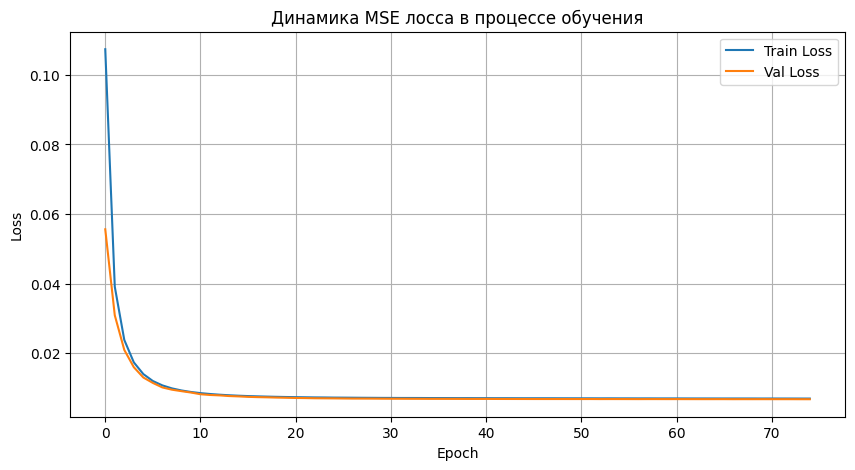

In [7]:
plt.figure(figsize=(10,5))
plt.plot(train_losses_history, label='Train Loss')
plt.plot(val_losses_history, label='Val Loss')
plt.title("Динамика MSE лосса в процессе обучения")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


## 6.2 Визуализация входа и выхода автоэнкодера

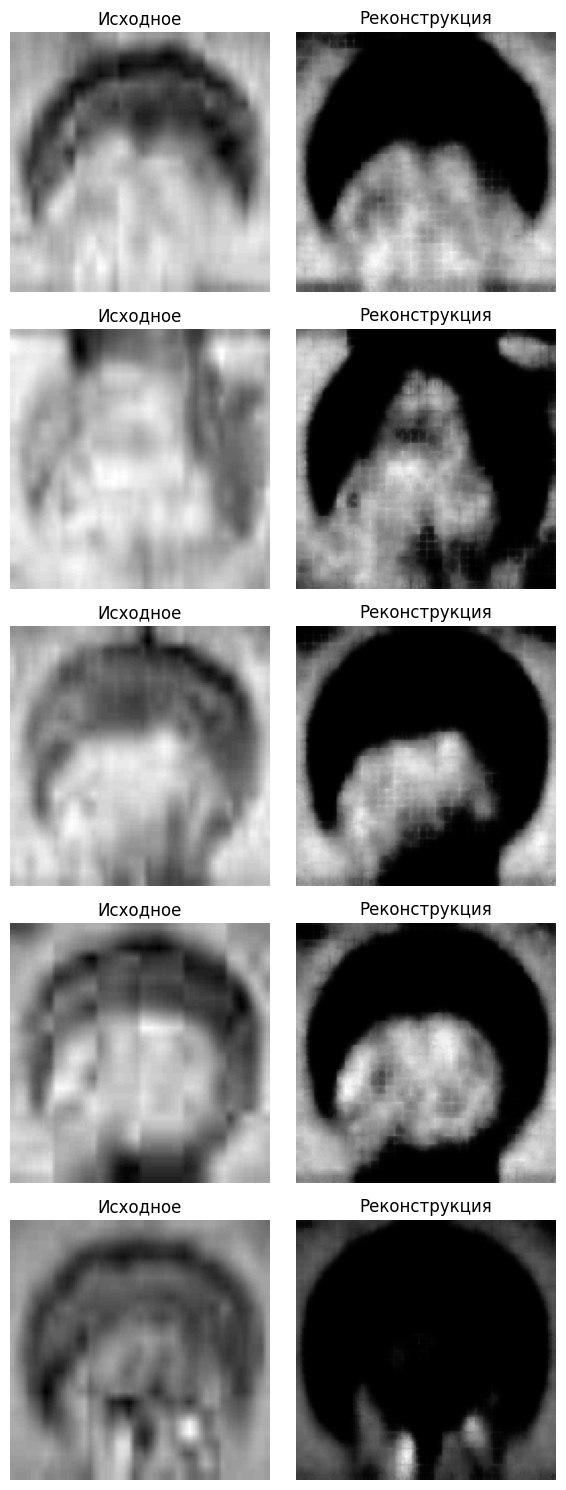

In [8]:
def visualize_reconstructions(model, dataset, num_images=5):
    model.eval()
    fig, axes = plt.subplots(num_images, 2, figsize=(6, 3*num_images))

    for i in range(num_images):
        # Случайный индекс
        idx = np.random.randint(0, len(dataset))
        img = dataset[idx]
        # img - это тензор размера (1, H, W)
        input_batch = img.unsqueeze(0).to(device)  # (1, 1, H, W)

        with torch.no_grad():
            output = model(input_batch)

        # Превращаем обратно в numpy
        input_np = img.squeeze().numpy()      # (H, W)
        output_np = output.squeeze().cpu().numpy()  # (H, W)

        # Отрисовываем
        axes[i, 0].imshow(input_np, cmap='gray')
        axes[i, 0].set_title("Исходное")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(output_np, cmap='gray')
        axes[i, 1].set_title("Реконструкция")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()


# Пример вызова:
visualize_reconstructions(model, val_dataset, num_images=5)


# 7. Поиск порога и расчёт метрик

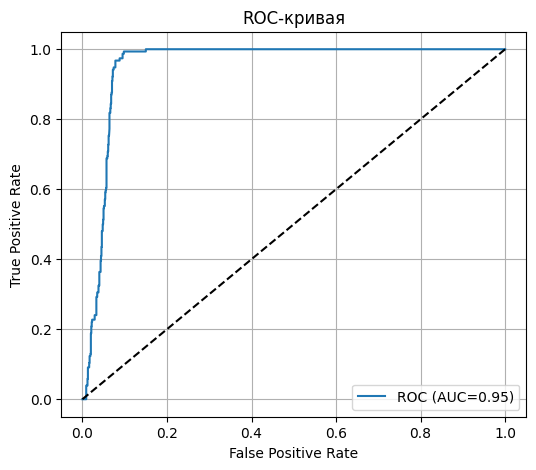

Optimal threshold=0.012676, ROC-AUC=0.953
TPR=99.35%, TNR=90.20%


In [9]:
def compute_mse_losses(model, loader):
    """
    Прогоняем все батчи из loader, считаем MSE для каждого изображения.
    Возвращаем список (или numpy-массив) всех MSE.
    """
    model.eval()
    criterion_local = nn.MSELoss(reduction='mean')
    losses = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            outputs = model(batch)
            loss = criterion_local(outputs, batch).item()
            losses.append(loss)

    return np.array(losses)


def find_optimal_threshold(model, val_loader, proliv_loader, plot_roc=True):
    """
    Ищем оптимальный порог MSE, который лучше всего разделяет
    'не_пролив' (0) и 'пролив' (1).
    """
    losses_non_proliv = compute_mse_losses(model, val_loader)   # MSE на валидационных не_проливах
    losses_proliv     = compute_mse_losses(model, proliv_loader)# MSE на проливах

    y_true = np.concatenate([
        np.zeros_like(losses_non_proliv),
        np.ones_like(losses_proliv)
    ])

    all_losses = np.concatenate([losses_non_proliv, losses_proliv])

    # Строим ROC-кривую
    fpr, tpr, thresholds = roc_curve(y_true, all_losses)
    roc_auc = auc(fpr, tpr)

    # Индекс оптимального порога
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Для интереса посчитаем TPR и TNR при этом пороге
    # Предсказание: 1 (пролив), если mse >= threshold
    predictions = (all_losses >= optimal_threshold).astype(int)

    # TPR: TP / (TP + FN) = доля правильно найденных проливов
    tp = np.sum((predictions == 1) & (y_true == 1))
    fn = np.sum((predictions == 0) & (y_true == 1))
    tpr_opt = tp / (tp + fn) if (tp + fn) else 0

    # TNR: TN / (TN + FP) = доля правильно найденных не_проливов
    tn = np.sum((predictions == 0) & (y_true == 0))
    fp = np.sum((predictions == 1) & (y_true == 0))
    tnr_opt = tn / (tn + fp) if (tn + fp) else 0

    if plot_roc:
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.2f})")
        plt.plot([0,1],[0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-кривая")
        plt.legend()
        plt.grid(True)
        plt.show()

    return optimal_threshold, roc_auc, tpr_opt, tnr_opt


optimal_threshold, roc_auc_val, tpr_opt, tnr_opt = find_optimal_threshold(model, val_loader, proliv_loader, plot_roc=True)
print(f"Optimal threshold={optimal_threshold:.6f}, ROC-AUC={roc_auc_val:.3f}")
print(f"TPR={tpr_opt:.2%}, TNR={tnr_opt:.2%}")


# 8. Тест


Вычисление ошибок для 9000 изображений...
Вычисление завершено за 28.76 секунд.
Вычисление ошибок для 154 изображений...
Вычисление завершено за 0.56 секунд.


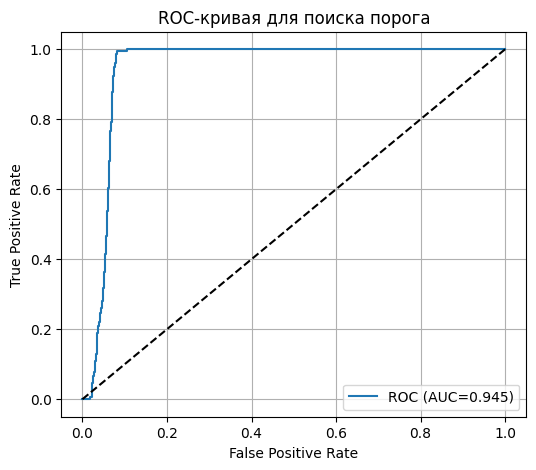

--- Результаты поиска порога ---
Найденный робастный порог = 0.086838
ROC-AUC на данных для поиска порога = 0.945
На этих же данных: TPR=99.35%, TNR=91.90%
------------------------------

--- ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА ТЕСТЕ ---
На тесте: TPR=97.67%, TNR=80.82%


In [14]:
# ===================================================================
# 7. Поиск РОБАСТНОГО порога и расчёт метрик
# Мы используем весь TRAIN датасет для получения стабильной оценки
# ошибки на "нормальных" данных.
# ===================================================================

# Вспомогательные функции, необходимые для этой ячейки

def compute_losses(model, loader, loss_fn=nn.L1Loss()):
    """
    Прогоняем все батчи из loader, считаем ошибку L1 для каждого изображения.
    Эта функция корректно работает с любым размером батча.
    """
    model.eval()
    losses = []

    print(f"Вычисление ошибок для {len(loader.dataset)} изображений...")
    start_time = time.time()
    
    with torch.no_grad():
        for batch in loader:
            # Итерируемся по каждому изображению в батче, чтобы получить индивидуальную ошибку
            for i in range(batch.size(0)):
                single_img = batch[i].unsqueeze(0).to(device)
                output = model(single_img)
                loss = loss_fn(output, single_img).item()
                losses.append(loss)
                
    end_time = time.time()
    print(f"Вычисление завершено за {end_time - start_time:.2f} секунд.")
    return np.array(losses)


def find_optimal_threshold(model, normal_loader, anomaly_loader, plot_roc=True):
    """
    Ищем оптимальный порог, который лучше всего разделяет
    'нормальные' (0) и 'аномальные' (1) данные.
    """
    # Вычисляем ошибки на большом наборе "нормальных" данных
    losses_normal = compute_losses(model, normal_loader)
    
    # Вычисляем ошибки на "аномальных" данных
    losses_anomaly = compute_losses(model, anomaly_loader)

    # Собираем все данные для ROC-анализа
    y_true = np.concatenate([
        np.zeros_like(losses_normal),
        np.ones_like(losses_anomaly)
    ])
    all_losses = np.concatenate([losses_normal, losses_anomaly])

    # Строим ROC-кривую
    fpr, tpr, thresholds = roc_curve(y_true, all_losses)
    roc_auc = auc(fpr, tpr)

    # Находим индекс порога, который максимизирует (TPR - FPR)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = thresholds[optimal_idx]

    # Для отладки считаем TPR и TNR на данных, по которым искали порог
    predictions = (all_losses >= optimal_threshold).astype(int)
    tp = np.sum((predictions == 1) & (y_true == 1)); fn = np.sum((predictions == 0) & (y_true == 1))
    tn = np.sum((predictions == 0) & (y_true == 0)); fp = np.sum((predictions == 1) & (y_true == 0))
    tpr_opt = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr_opt = tn / (tn + fp) if (tn + fp) > 0 else 0

    if plot_roc:
        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"ROC (AUC={roc_auc:.3f})")
        plt.plot([0,1],[0,1], 'k--')
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC-кривая для поиска порога")
        plt.legend()
        plt.grid(True)
        plt.show()

    return optimal_threshold, roc_auc, tpr_opt, tnr_opt

# --- ОСНОВНАЯ ЛОГИКА ---

# Создаем DataLoader для ВСЕХ обучающих данных без перемешивания,
# чтобы получить стабильное распределение ошибок "нормы".
robust_train_loader = DataLoader(train_dataset, batch_size=32, shuffle=False)

# Находим порог, сравнивая ошибки на ВСЕХ "хороших" картинках с ошибками на "плохих"
optimal_threshold, roc_auc_val, tpr_opt, tnr_opt = find_optimal_threshold(model, robust_train_loader, proliv_loader, plot_roc=True)

print("--- Результаты поиска порога ---")
print(f"Найденный робастный порог = {optimal_threshold:.6f}")
print(f"ROC-AUC на данных для поиска порога = {roc_auc_val:.3f}")
print(f"На этих же данных: TPR={tpr_opt:.2%}, TNR={tnr_opt:.2%}")
print("-" * 30)


# =======================================================
# 8. Финальный Тест с новым, робастным порогом
# =======================================================

# Вспомогательные функции для теста (дублируем на случай запуска только этой ячейки)
class SortedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.image_paths = sorted([
            os.path.join(root_dir, f)
            for f in os.listdir(root_dir)
            if f.lower().endswith(('.jpg', '.png', '.jpeg'))
        ])
        self.transform = transform
    def __len__(self): return len(self.image_paths)
    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("L")
        if self.transform: image = self.transform(image)
        return image

def read_test_annotations(annotations_file):
    d = {}
    with open(annotations_file, 'r') as f:
        for line in f:
            filename, lbl_str = line.strip().split()
            d[filename] = int(lbl_str)
    return d

def eval_on_test(model, test_dataset, annotations_file, threshold):
    ann_dict = read_test_annotations(annotations_file)
    model.eval()
    criterion_local = nn.L1Loss()
    losses = []
    y_true = []

    # Используем DataLoader для удобства
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

    for i, img in enumerate(test_loader):
        path = test_dataset.image_paths[i]
        filename = os.path.basename(path)
        
        img = img.to(device)
        with torch.no_grad():
            out = model(img)
            loss = criterion_local(out, img).item()

        losses.append(loss)
        y_true.append(ann_dict[filename])

    losses = np.array(losses); y_true = np.array(y_true)
    preds = (losses >= threshold).astype(int)

    tp = np.sum((preds == 1) & (y_true == 1)); fn = np.sum((preds == 0) & (y_true == 1))
    fp = np.sum((preds == 1) & (y_true == 0)); tn = np.sum((preds == 0) & (y_true == 0))

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
    return tpr, tnr

# --- ЗАПУСК ТЕСТА ---
test_dir = "dataset/dataset/test/imgs"
test_annotation = "dataset/dataset/test/test_annotation.txt"

# transform_val_test уже определен в ячейке In[3] и не содержит аугментаций/нормализации
test_dataset = SortedDataset(test_dir, transform=transform_val_test)

# Тестируем с новым, более надежным порогом
tpr_test, tnr_test = eval_on_test(model, test_dataset, test_annotation, threshold=optimal_threshold)
print("\n--- ФИНАЛЬНЫЙ РЕЗУЛЬТАТ НА ТЕСТЕ ---")
print(f"На тесте: TPR={tpr_test:.2%}, TNR={tnr_test:.2%}")